In [58]:
print('test')

test


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
from sklearn.metrics import classification_report

df = pd.read_csv('./dataset/hotel_booking.csv', encoding='utf-8')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [2]:
df2 = df.copy()

In [3]:
# children의 결측치는 0으로 처리 후 정수형으로 바꿈
df2["children"] = df2["children"].fillna(0).astype(int)

In [4]:
# 투숙객 0명 값 제거
df2 = df2[
    (df2["adults"] + df2["children"] + df2["babies"]) > 0
]

print("제거 후 데이터 크기:", df2.shape)

제거 후 데이터 크기: (119210, 36)


In [5]:
# children / babies 극단값 제거
df2 = df2[
    (df2["children"] < 5) &
    (df2["babies"] < 5)
]

print("제거 후 데이터 크기:", df2.shape)

제거 후 데이터 크기: (119207, 36)


In [6]:
# 파생변수 : 성인+아동+영아 -> 투숙객 수 
df2["total_guests"] = (
    df2["adults"]
    + df2["children"]
    + df2["babies"]
)

# 파생변수 : 아이 동반
df2["has_children"] = (
    (df2["children"] + df2["babies"]) > 0
).astype(int)

# 원본 제거
df2 = df2.drop(columns=["adults", "children", "babies"])

In [7]:
# agent / company는 ID 대신 이용 여부 변수 생성
df2["has_agent"] = df2["agent"].notna().astype(int)
df2["has_company"] = df2["company"].notna().astype(int)

# 원본 제거
df2 = df2.drop(columns=["agent", "company"])

In [8]:
# 총 숙박일수
df2["total_nights"] = (
    df2["stays_in_weekend_nights"]
    + df2["stays_in_week_nights"]
)

# 주말 포함 여부
df2["has_weekend_stay"] = (
    df2["stays_in_weekend_nights"] > 0
).astype(int)

In [9]:
# 숙박일수 0 제거 및 관련 컬럼 삭제
df2 = df2[df2["total_nights"] > 0]
print("0박 예약 제거 후 데이터 크기:", df2.shape)

df2 = df2.drop(
    columns=[
        "stays_in_weekend_nights",
        "stays_in_week_nights",
        "has_weekend_stay"
    ]
)

0박 예약 제거 후 데이터 크기: (118562, 37)


In [10]:
print("남은 0박 예약:", (df2["total_nights"] == 0).sum())

남은 0박 예약: 0


In [11]:
# 파생컬럼 : 예약 대기시간 유무
df2["has_waiting_list"] = (df2["days_in_waiting_list"] > 0).astype(int)

# 관련 컬럼 삭제
df2 = df2.drop(
    columns=["days_in_waiting_list"]
)

In [12]:
# country 결측치 처리 : unknown
df2["country"] = df2["country"].fillna("Unknown")

In [13]:
# 178개국 -> 상위 10개 + other 로 정리
top_countries = (
    df2["country"]
    .value_counts()
    .head(10)
    .index
)

df2["country_group"] = df2["country"].where(
    df2["country"].isin(top_countries),
    "Other"
)

# 관련 컬럼 삭제
df2 = df2.drop(columns=["country"])

In [14]:
# 제거해야 할 컬럼
drop_cols=['name', 'email', 'phone-number', 'credit_card', 
           'reservation_status', 'reservation_status_date', 'assigned_room_type',
           'arrival_date_day_of_month', 'arrival_date_week_number',
           'arrival_date_year', 'booking_changes', 'distribution_channel', 'deposit_type']

df2 = df2.drop(columns=drop_cols)

In [15]:
print("데이터 크기:", df2.shape)
print("컬럼명:", df2.columns)

데이터 크기: (118562, 21)
컬럼명: Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_month', 'meal',
       'market_segment', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type', 'customer_type',
       'adr', 'required_car_parking_spaces', 'total_of_special_requests',
       'total_guests', 'has_children', 'has_agent', 'has_company',
       'total_nights', 'has_waiting_list', 'country_group'],
      dtype='str')


In [16]:
df2.info()

<class 'pandas.DataFrame'>
Index: 118562 entries, 2 to 119389
Data columns (total 21 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           118562 non-null  str    
 1   is_canceled                     118562 non-null  int64  
 2   lead_time                       118562 non-null  int64  
 3   arrival_date_month              118562 non-null  str    
 4   meal                            118562 non-null  str    
 5   market_segment                  118562 non-null  str    
 6   is_repeated_guest               118562 non-null  int64  
 7   previous_cancellations          118562 non-null  int64  
 8   previous_bookings_not_canceled  118562 non-null  int64  
 9   reserved_room_type              118562 non-null  str    
 10  customer_type                   118562 non-null  str    
 11  adr                             118562 non-null  float64
 12  required_car_parking_spaces     

In [75]:
# 결측치가 있는 컬럼만 확인
null_count = df2.isnull().sum()
print(null_count[null_count > 0])

Series([], dtype: int64)


In [76]:
print("df2 중복 데이터 수:", df2.duplicated().sum())
print("df 중복 데이터 수:", df.duplicated().sum())

df2 중복 데이터 수: 34807
df 중복 데이터 수: 0


In [17]:
# 수치형 컬럼 수 정리
numeric_df = df2.select_dtypes(include="number")

print(numeric_df.columns)
print("수치형 컬럼 수:", len(numeric_df.columns))

Index(['is_canceled', 'lead_time', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'total_guests', 'has_children', 'has_agent', 'has_company',
       'total_nights', 'has_waiting_list'],
      dtype='str')
수치형 컬럼 수: 14


d:\pythonscript\ML_PRJ\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
d:\pythonscript\ML_PRJ\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


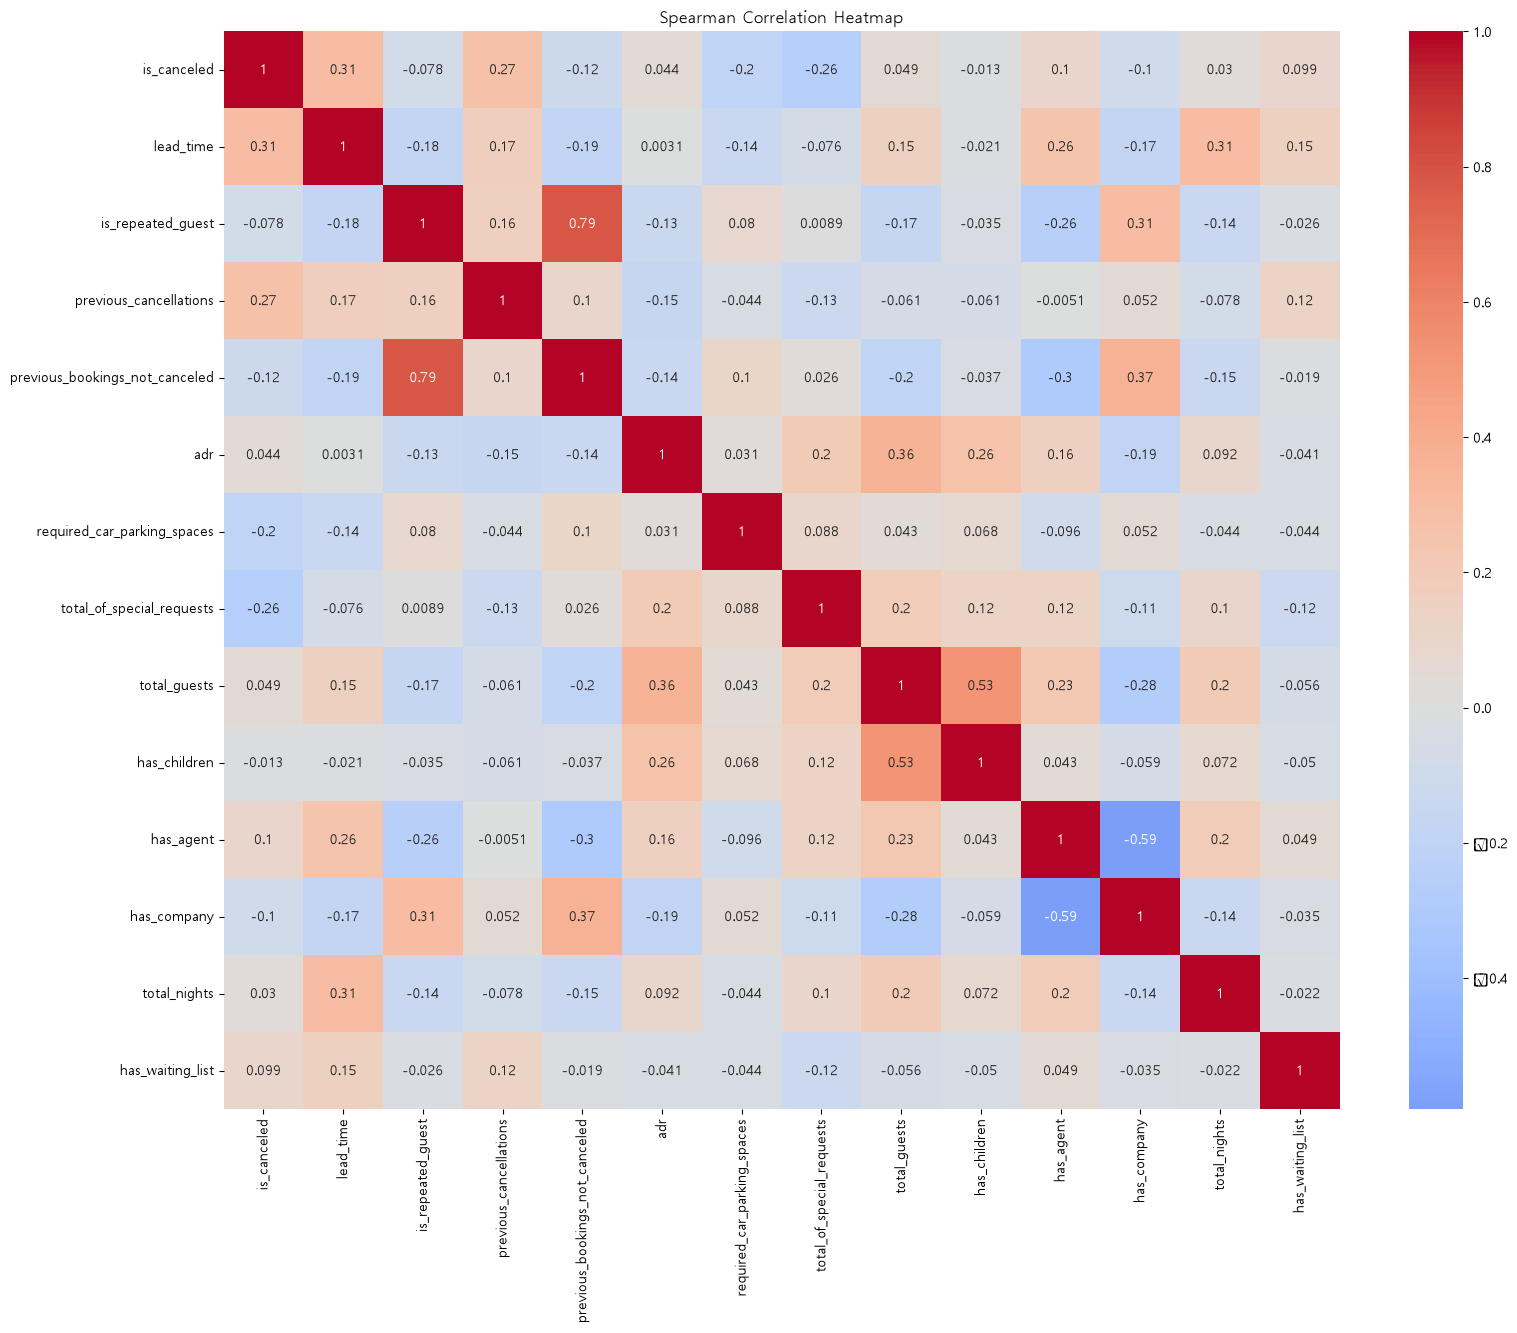

In [78]:
plt.figure(figsize=(18, 14))

corr = numeric_df.corr(method="spearman")

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True
)

plt.title("Spearman Correlation Heatmap")
plt.show()

In [79]:
cancel_corr = (
    corr["is_canceled"]
    .drop("is_canceled")
    .sort_values(key=abs, ascending=False)
)

cancel_corr

lead_time                         0.314588
previous_cancellations            0.270107
total_of_special_requests        -0.260177
required_car_parking_spaces      -0.198726
previous_bookings_not_canceled   -0.115706
has_agent                         0.101080
has_company                      -0.099721
has_waiting_list                  0.098765
is_repeated_guest                -0.077793
total_guests                      0.049323
adr                               0.043862
total_nights                      0.030425
has_children                     -0.013201
Name: is_canceled, dtype: float64

d:\pythonscript\ML_PRJ\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


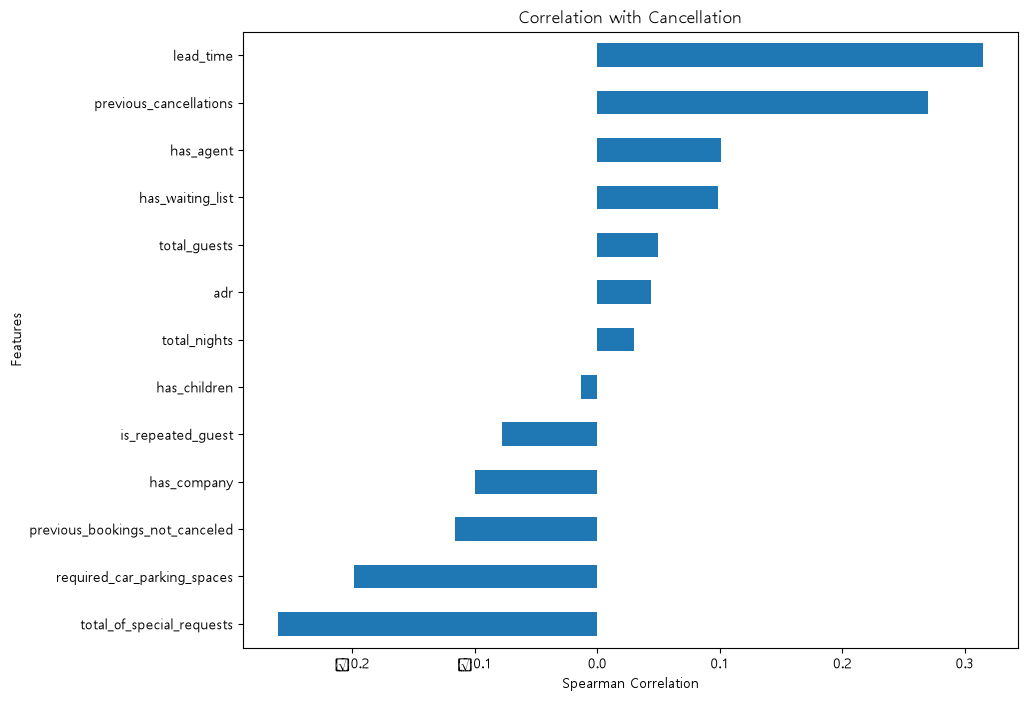

In [80]:
plt.figure(figsize=(10, 8))

cancel_corr.sort_values().plot(kind="barh")

plt.title("Correlation with Cancellation")
plt.xlabel("Spearman Correlation")
plt.ylabel("Features")
plt.show()

In [81]:
# 범주형 변수
categorical_cols = [
    "hotel",
    "arrival_date_month",
    "meal",
    "country_group",
    "market_segment",
    "reserved_room_type",
    "customer_type"
]

In [82]:
# 범주형 변수 컬럼 수 확인
for col in categorical_cols:
    print(f"{col}: {df2[col].nunique()}개")

hotel: 2개
arrival_date_month: 12개
meal: 5개
country_group: 11개
market_segment: 8개
reserved_room_type: 9개
customer_type: 4개


In [83]:
for col in categorical_cols:
    print(f"\n===== {col} =====")

    result = (
        df2.groupby(col)["is_canceled"]
        .agg(["count", "mean"])
        .sort_values("count", ascending=False)
    )

    display(result)


===== hotel =====


,count,mean
hotel,,
City Hotel,78897,0.419103
Resort Hotel,39665,0.280071



===== arrival_date_month =====


,count,mean
arrival_date_month,,
August,13812,0.379163
July,12585,0.376242
May,11704,0.399436
October,11063,0.383711
April,11045,0.408782
June,10891,0.416123
September,10477,0.392670
March,9716,0.323796
February,7998,0.335834



===== meal =====


...

,count,mean
market_segment,,
Online TA,56128,0.369210
Offline TA/TO,24048,0.345143
Groups,19759,0.612025
Direct,12449,0.155033
Corporate,5230,0.189101
Complementary,715,0.121678
Aviation,231,0.220779
Undefined,2,1.000000



===== reserved_room_type =====


,count,mean
reserved_room_type,,
A,85397,0.393538
D,19094,0.319315
E,6482,0.294199
F,2879,0.305662
G,2074,0.367888
B,1110,0.330631
C,923,0.332611
H,597,0.410385
L,6,0.333333



===== customer_type =====


,count,mean
customer_type,,
Transient,88934,0.410113
Transient-Party,25004,0.255279
Contract,4055,0.310974
Group,569,0.101933


### 머신러닝 시작

In [18]:
categorical_cols = [
    "hotel",
    "arrival_date_month",
    "meal",
    "market_segment",
    "reserved_room_type",
    "customer_type",
    "country_group"
]

numeric_cols = [
    "lead_time",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "has_agent",
    "has_company",
    "total_guests",
    "total_nights",
    "has_waiting_list",
    "has_children"
]

feature_cols = categorical_cols + numeric_cols

In [85]:
print("Feature 수:", len(feature_cols))
print(feature_cols)

Feature 수: 20
['hotel', 'arrival_date_month', 'meal', 'market_segment', 'reserved_room_type', 'customer_type', 'country_group', 'lead_time', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'has_agent', 'has_company', 'total_guests', 'total_nights', 'has_waiting_list', 'has_children']


In [19]:
# 학습 데이터 분리
X = df2[feature_cols]
y = df2["is_canceled"]

In [20]:
print("X:", X.shape)
print("y:", y.shape)

print("\nTarget 분포")
print(y.value_counts())
print(y.value_counts(normalize=True))

X: (118562, 20)
y: (118562,)

Target 분포
is_canceled
0    74387
1    44175
Name: count, dtype: int64
is_canceled
0    0.62741
1    0.37259
Name: proportion, dtype: float64


In [21]:
# Train / Test 분리
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [89]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\n전체 취소율")
print(y.mean())

print("Train 취소율")
print(y_train.mean())

print("Test 취소율")
print(y_test.mean())

X_train: (94849, 20)
X_test : (23713, 20)

전체 취소율
0.3725898685919603
Train 취소율
0.3725922255374332
Test 취소율
0.37258044110825284


In [22]:
# One-Hot Encoding + Scaling 준비

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [23]:
# 범주형
categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [24]:
# 수치형
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [26]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("변환 전 X_train:", X_train.shape)
print("변환 후 X_train:", X_train_processed.shape)

print("변환 전 X_test:", X_test.shape)
print("변환 후 X_test:", X_test_processed.shape)

변환 전 X_train: (94849, 20)
변환 후 X_train: (94849, 64)
변환 전 X_test: (23713, 20)
변환 후 X_test: (23713, 64)


In [27]:
processed_feature_names = (
    preprocessor.get_feature_names_out()
)

print("전처리 후 Feature 수:", len(processed_feature_names))
print(processed_feature_names)

전처리 후 Feature 수: 64
['num__lead_time' 'num__is_repeated_guest' 'num__previous_cancellations'
 'num__previous_bookings_not_canceled' 'num__adr'
 'num__required_car_parking_spaces' 'num__total_of_special_requests'
 'num__has_agent' 'num__has_company' 'num__total_guests'
 'num__total_nights' 'num__has_waiting_list' 'num__has_children'
 'cat__hotel_City Hotel' 'cat__hotel_Resort Hotel'
 'cat__arrival_date_month_April' 'cat__arrival_date_month_August'
 'cat__arrival_date_month_December' 'cat__arrival_date_month_February'
 'cat__arrival_date_month_January' 'cat__arrival_date_month_July'
 'cat__arrival_date_month_June' 'cat__arrival_date_month_March'
 'cat__arrival_date_month_May' 'cat__arrival_date_month_November'
 'cat__arrival_date_month_October' 'cat__arrival_date_month_September'
 'cat__meal_BB' 'cat__meal_FB' 'cat__meal_HB' 'cat__meal_SC'
 'cat__meal_Undefined' 'cat__market_segment_Aviation'
 'cat__market_segment_Complementary' 'cat__market_segment_Corporate'
 'cat__market_segment_Direc

In [96]:
# 로지스틱 회귀
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [97]:
lr_pipeline.fit(X_train, y_train)
y_pred = lr_pipeline.predict(X_test)
y_proba = lr_pipeline.predict_proba(X_test)[:, 1]

In [98]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.802
Precision: 0.7742
Recall   : 0.6613
F1 Score : 0.7133
ROC-AUC  : 0.8772

Confusion Matrix
[[13174  1704]
 [ 2992  5843]]


In [99]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.89      0.85     14878
           1       0.77      0.66      0.71      8835

    accuracy                           0.80     23713
   macro avg       0.79      0.77      0.78     23713
weighted avg       0.80      0.80      0.80     23713



In [100]:
import pandas as pd

model_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": 0.8020,
        "Precision": 0.7742,
        "Recall": 0.6613,
        "F1 Score": 0.7133,
        "ROC-AUC": 0.8772
    }
])

model_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.802,0.7742,0.6613,0.7133,0.8772


In [28]:
# 랜덤 포레스트
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200, 
        random_state=42,
        n_jobs=-1       # CPU 코어를 최대한 사용해서 학습 속도를 높이는 옵션
    ))
])

rf_pipeline.fit(X_train, y_train);

In [29]:
rf_pred = rf_pipeline.predict(X_test)
rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]

In [30]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_proba)

print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_roc_auc, 4))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report")
print(classification_report(y_test, rf_pred))

Accuracy : 0.878
Precision: 0.862
Recall   : 0.8006
F1 Score : 0.8302
ROC-AUC  : 0.9481

Confusion Matrix
[[13746  1132]
 [ 1762  7073]]

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.92      0.90     14878
           1       0.86      0.80      0.83      8835

    accuracy                           0.88     23713
   macro avg       0.87      0.86      0.87     23713
weighted avg       0.88      0.88      0.88     23713



In [104]:
new_result = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Accuracy": rf_accuracy,
        "Precision": rf_precision,
        "Recall": rf_recall,
        "F1 Score": rf_f1,
        "ROC-AUC": rf_roc_auc
    }
])

model_results = pd.concat(
    [model_results, new_result],
    ignore_index=True
)

display(model_results.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.802,0.7742,0.6613,0.7133,0.8772
1,Random Forest,0.878,0.8620,0.8006,0.8302,0.9481


In [105]:
# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=100,       # 앞의 트리가 틀린 부분을 뒤의 트리가 보완 
                                #  -> 랜덤 포레스트처럼 많이 늘릴 필요 없음
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

gb_pipeline.fit(X_train, y_train);

In [106]:
gb_pred = gb_pipeline.predict(X_test)
gb_proba = gb_pipeline.predict_proba(X_test)[:, 1]

In [107]:
gb_accuracy = accuracy_score(y_test, gb_pred)
gb_precision = precision_score(y_test, gb_pred)
gb_recall = recall_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred)
gb_roc_auc = roc_auc_score(y_test, gb_proba)

print("Accuracy :", round(gb_accuracy, 4))
print("Precision:", round(gb_precision, 4))
print("Recall   :", round(gb_recall, 4))
print("F1 Score :", round(gb_f1, 4))
print("ROC-AUC  :", round(gb_roc_auc, 4))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, gb_pred))

print("\nClassification Report")
print(classification_report(y_test, gb_pred))

Accuracy : 0.831
Precision: 0.7997
Recall   : 0.7289
F1 Score : 0.7627
ROC-AUC  : 0.9104

Confusion Matrix
[[13265  1613]
 [ 2395  6440]]

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.89      0.87     14878
           1       0.80      0.73      0.76      8835

    accuracy                           0.83     23713
   macro avg       0.82      0.81      0.82     23713
weighted avg       0.83      0.83      0.83     23713



In [108]:
new_result = pd.DataFrame([
    {
        "Model": "Gradient Boosting",
        "Accuracy": gb_accuracy,
        "Precision": gb_precision,
        "Recall": gb_recall,
        "F1 Score": gb_f1,
        "ROC-AUC": gb_roc_auc
    }
])

model_results = pd.concat(
    [model_results, new_result],
    ignore_index=True
)

display(model_results.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.802,0.7742,0.6613,0.7133,0.8772
1,Random Forest,0.878,0.8620,0.8006,0.8302,0.9481
2,Gradient Boosting,0.831,0.7997,0.7289,0.7627,0.9104


In [109]:
# 결과 csv로 저장
model_results.to_csv(
    "model_results.csv",
    index=False,
    encoding="utf-8-sig"
)

In [110]:
# 랜덤포레스트 과적합 여부 확인

rf_train_pred = rf_pipeline.predict(X_train)
rf_train_proba = rf_pipeline.predict_proba(X_train)[:, 1]

rf_train_accuracy = accuracy_score(y_train, rf_train_pred)
rf_train_roc_auc = roc_auc_score(y_train, rf_train_proba)

print("Train Accuracy:", round(rf_train_accuracy, 4))
print("Test Accuracy :", round(rf_accuracy, 4))

print("Train ROC-AUC :", round(rf_train_roc_auc, 4))
print("Test ROC-AUC  :", round(rf_roc_auc, 4))

Train Accuracy: 0.9947
Test Accuracy : 0.878
Train ROC-AUC : 0.9995
Test ROC-AUC  : 0.9481


In [111]:
# 하이퍼파라미터 튜닝
# GridSearchCV 대신 RandomizedSearchCV
#   데이터가 9만 건 넘고, Random Forest 자체도 계산량이 있어서 
#   GridSearch를 크게 잡으면 시간이 오래걸림
# 1차 Broad RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

param_dist_broad = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [8, 10, 12, 15, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__max_features": ["sqrt", "log2"] 
    # log2 : 랜덤 포레스트에서 각 트리가 분할(split)을 만들 때 고려할 특성(feature)의 개수
}

search_broad = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist_broad,
    n_iter=12, 
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search_broad.fit(X_train, y_train);


Fitting 3 folds for each of 12 candidates, totalling 36 fits


In [112]:
print(search_broad.best_params_)
print(search_broad.best_score_)

{'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': None}
0.9411691058965528


In [113]:
# search_broad 최적 모델 성능 확인
broad_rf = search_broad.best_estimator_

broad_train_pred = broad_rf.predict(X_train)
broad_train_proba = broad_rf.predict_proba(X_train)[:, 1]

broad_test_pred = broad_rf.predict(X_test)
broad_test_proba = broad_rf.predict_proba(X_test)[:, 1]

print("Train Accuracy:", round(accuracy_score(y_train, broad_train_pred), 4))
print("Test Accuracy :", round(accuracy_score(y_test, broad_test_pred), 4))

print("Train ROC-AUC :", round(roc_auc_score(y_train, broad_train_proba), 4))
print("Test ROC-AUC  :", round(roc_auc_score(y_test, broad_test_proba), 4))

print("Precision     :", round(precision_score(y_test, broad_test_pred), 4))
print("Recall        :", round(recall_score(y_test, broad_test_pred), 4))
print("F1 Score      :", round(f1_score(y_test, broad_test_pred), 4))

Train Accuracy: 0.9336
Test Accuracy : 0.872
Train ROC-AUC : 0.9878
Test ROC-AUC  : 0.9463
Precision     : 0.8627
Recall        : 0.7808
F1 Score      : 0.8197


In [32]:
# 과적합 완화를 위한 규제 범위 탐색
from sklearn.model_selection import RandomizedSearchCV

param_dist_regularized = {
    "model__n_estimators": [150, 200, 300],
    "model__max_depth": [8, 10, 12, 15, 20],
    "model__min_samples_split": [5, 10, 20],
    "model__min_samples_leaf": [2, 5, 10],
    "model__max_features": ["sqrt", "log2"]
}

search_regularized = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist_regularized,
    n_iter=12,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search_regularized.fit(X_train, y_train);

Fitting 3 folds for each of 12 candidates, totalling 36 fits


In [33]:
print(search_regularized.best_params_)
print(search_regularized.best_score_)

{'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 'log2', 'model__max_depth': 20}
0.9331107836884206


In [34]:
# 규제 search 최적 모델 성능 확인
regularized_rf = search_regularized.best_estimator_

reg_train_pred = regularized_rf.predict(X_train)
reg_train_proba = regularized_rf.predict_proba(X_train)[:, 1]

reg_test_pred = regularized_rf.predict(X_test)
reg_test_proba = regularized_rf.predict_proba(X_test)[:, 1]

print("Train Accuracy:", round(accuracy_score(y_train, reg_train_pred), 4))
print("Test Accuracy :", round(accuracy_score(y_test, reg_test_pred), 4))

print("Train ROC-AUC :", round(roc_auc_score(y_train, reg_train_proba), 4))
print("Test ROC-AUC  :", round(roc_auc_score(y_test, reg_test_proba), 4))

print("Precision     :", round(precision_score(y_test, reg_test_pred), 4))
print("Recall        :", round(recall_score(y_test, reg_test_pred), 4))
print("F1 Score      :", round(f1_score(y_test, reg_test_pred), 4))


Train Accuracy: 0.8751
Test Accuracy : 0.8598
Train ROC-AUC : 0.9564
Test ROC-AUC  : 0.9363
Precision     : 0.866
Recall        : 0.738
F1 Score      : 0.7969


In [ ]:
# Random Forest 과적합 비교 결과 저장
rf_overfitting_results = pd.DataFrame([
    {
        "Model": "Random Forest - Baseline",
        "Train Accuracy": rf_train_accuracy,
        "Test Accuracy": rf_accuracy,
        "Train ROC-AUC": rf_train_roc_auc,
        "Test ROC-AUC": rf_roc_auc,
        "Precision": rf_precision,
        "Recall": rf_recall,
        "F1 Score": rf_f1
    },
    {
        "Model": "Random Forest - Broad RandomizedSearchCV",
        "Train Accuracy": accuracy_score(y_train, broad_train_pred),
        "Test Accuracy": accuracy_score(y_test, broad_test_pred),
        "Train ROC-AUC": roc_auc_score(y_train, broad_train_proba),
        "Test ROC-AUC": roc_auc_score(y_test, broad_test_proba),
        "Precision": precision_score(y_test, broad_test_pred),
        "Recall": recall_score(y_test, broad_test_pred),
        "F1 Score": f1_score(y_test, broad_test_pred)
    },
    {
        "Model": "Random Forest - Regularized Search",
        "Train Accuracy": accuracy_score(y_train, reg_train_pred),
        "Test Accuracy": accuracy_score(y_test, reg_test_pred),
        "Train ROC-AUC": roc_auc_score(y_train, reg_train_proba),
        "Test ROC-AUC": roc_auc_score(y_test, reg_test_proba),
        "Precision": precision_score(y_test, reg_test_pred),
        "Recall": recall_score(y_test, reg_test_pred),
        "F1 Score": f1_score(y_test, reg_test_pred)
    }
])

display(rf_overfitting_results.round(4))

,Model,Train Accuracy,Test Accuracy,Train ROC-AUC,Test ROC-AUC,Precision,Recall,F1 Score
0,Random Forest - Baseline,0.9947,0.8780,0.9995,0.9481,0.8620,0.8006,0.8302
1,Random Forest - Broad RandomizedSearchCV,0.9336,0.8720,0.9878,0.9463,0.8627,0.7808,0.8197
2,Random Forest - Regularized Search,0.8751,0.8598,0.9564,0.9363,0.8660,0.7380,0.7969


In [ ]:
rf_overfitting_results.to_csv(
    "rf_overfitting_results.csv",
    index=False,
    encoding="utf-8-sig"
)

In [36]:
# Permutation Importance
# Train을 다시 Sub-train / Validation으로 분리
from sklearn.model_selection import train_test_split
from sklearn.base import clone

X_subtrain, X_val, y_subtrain, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [37]:
# 현재 최종 후보인 규제 Random Forest를 복제해서 다시 학습
rf_for_importance = clone(regularized_rf)

rf_for_importance.fit(
    X_subtrain,
    y_subtrain
);

In [38]:
# 최종 모델을 평가할 때 중요하게 본 ROC-AUC가 
# 각 Feature를 섞었을 때 얼마나 떨어지는지 확인

from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    rf_for_importance,
    X_val,
    y_val,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

In [39]:
importance_df = pd.DataFrame({
    "Feature": X_val.columns,
    "Importance": perm_result.importances_mean,
    "Std": perm_result.importances_std
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

display(importance_df)

,Feature,Importance,Std
0,country_group,0.144925,0.001802
1,market_segment,0.066426,0.000982
2,customer_type,0.057091,0.000698
3,total_of_special_requests,0.052880,0.001359
4,lead_time,0.051438,0.000863
5,required_car_parking_spaces,0.020054,0.001399
6,previous_cancellations,0.014743,0.000596
7,adr,0.014404,0.000447
8,arrival_date_month,0.009906,0.000305
9,hotel,0.009761,0.000567


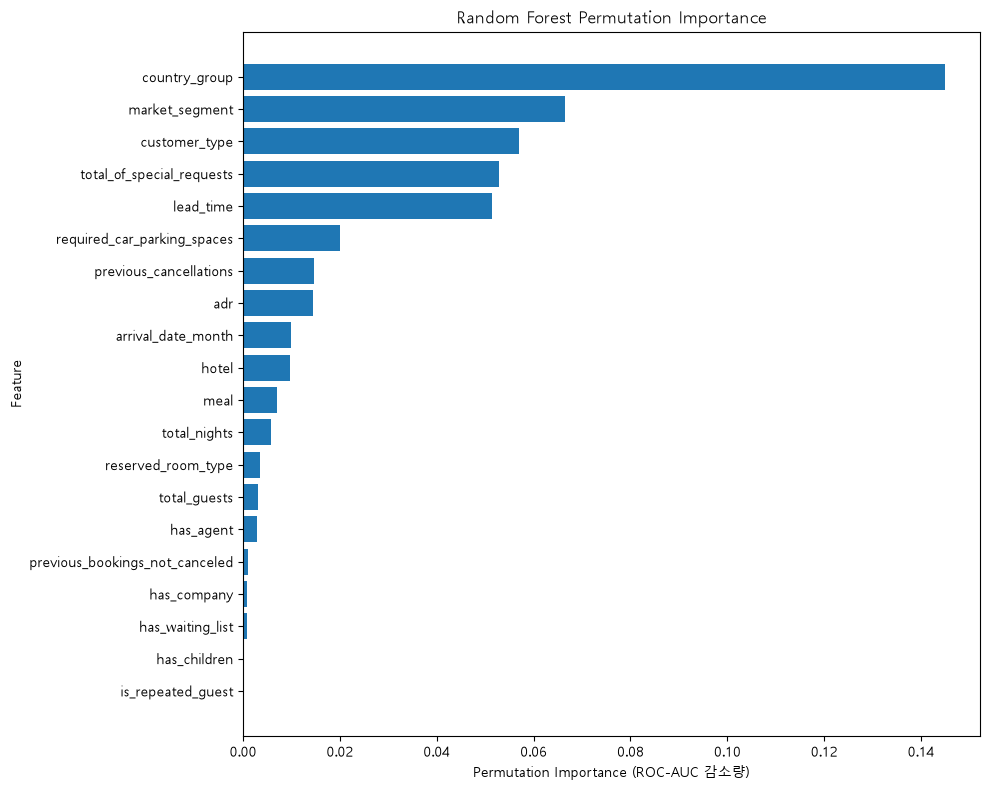

In [40]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'

plt.figure(figsize=(10, 8))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Permutation Importance (ROC-AUC 감소량)")
plt.ylabel("Feature")
plt.title("Random Forest Permutation Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Feature 축소 실험
drop_features = [
    "is_repeated_guest"
]

X_train_reduced = X_train.drop(columns=drop_features)

numeric_cols_reduced = [
    col for col in numeric_cols
    if col not in drop_features
]

In [ ]:
preprocessor_reduced = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols_reduced),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_reduced = Pipeline([
    ("preprocessor", preprocessor_reduced),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_split=10,
        min_samples_leaf=2,
        max_features="log2",
        random_state=42,
        n_jobs=-1
    ))
])

rf_reduced.fit(
    X_subtrain,
    y_subtrain
);

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_val_pred = rf_reduced.predict(X_val)
y_val_proba = rf_reduced.predict_proba(X_val)[:, 1]

print("Validation Accuracy :", accuracy_score(y_val, y_val_pred))
print("Validation Precision:", precision_score(y_val, y_val_pred))
print("Validation Recall   :", recall_score(y_val, y_val_pred))
print("Validation F1       :", f1_score(y_val, y_val_pred))
print("Validation ROC-AUC  :", roc_auc_score(y_val, y_val_proba))

Validation Accuracy : 0.8542435424354243
Validation Precision: 0.8603249037012226
Validation Recall   : 0.726796830786644
Validation F1       : 0.7879438607255158
Validation ROC-AUC  : 0.9331282879699397


In [ ]:
X_subtrain_full, X_val_full, y_subtrain_full, y_val_full = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [ ]:
preprocessor_full = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [ ]:
rf_full = Pipeline([
    ("preprocessor", preprocessor_full),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_split=10,
        min_samples_leaf=2,
        max_features="log2",
        random_state=42,
        n_jobs=-1
    ))
])

rf_full.fit(X_subtrain_full, y_subtrain_full);

In [ ]:
y_val_full_pred = rf_full.predict(X_val_full)
y_val_full_proba = rf_full.predict_proba(X_val_full)[:, 1]

print("20 Feature Accuracy :", accuracy_score(y_val_full, y_val_full_pred))
print("20 Feature Precision:", precision_score(y_val_full, y_val_full_pred))
print("20 Feature Recall   :", recall_score(y_val_full, y_val_full_pred))
print("20 Feature F1       :", f1_score(y_val_full, y_val_full_pred))
print("20 Feature ROC-AUC  :", roc_auc_score(y_val_full, y_val_full_proba))

20 Feature Accuracy : 0.8570901423299947
20 Feature Precision: 0.8594291371060881
20 Feature Recall   : 0.7369835880022637
20 Feature F1       : 0.7935105491659684
20 Feature ROC-AUC  : 0.9345547886973955


In [ ]:
# 강한 규제와 Baseline 사이의 중간값을 찾기 위해 수동으로 완화된 규제 적용
rf_moderate = Pipeline([
    ("preprocessor", preprocessor_full),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=25,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="log2",
        random_state=42,
        n_jobs=-1
    ))
])

rf_moderate.fit(X_subtrain_full, y_subtrain_full);

In [ ]:
y_val_pred = rf_moderate.predict(X_val_full)
y_val_proba = rf_moderate.predict_proba(X_val_full)[:, 1]

print("Accuracy :", accuracy_score(y_val_full, y_val_pred))
print("Precision:", precision_score(y_val_full, y_val_pred))
print("Recall   :", recall_score(y_val_full, y_val_pred))
print("F1       :", f1_score(y_val_full, y_val_pred))
print("ROC-AUC  :", roc_auc_score(y_val_full, y_val_proba))

Accuracy : 0.8629942013705851
Precision: 0.8608105926045535
Recall   : 0.7542444821731749
F1       : 0.8040117638187165
ROC-AUC  : 0.940071961720586


In [ ]:
## 모델의 성능이 약간 아쉬워 분석을 확장하고자 함 => 예약 금액과 결합하여 손실 위험도 판단

In [ ]:
val_result = X_val_full.copy()

# 실제 취소 여부
val_result["actual_canceled"] = y_val_full.values

# 모델이 예측한 취소 확률
val_result["cancel_probability"] = y_val_proba

# 예상 예약 금액
val_result["booking_amount"] = (
    val_result["adr"] * val_result["total_nights"]
)

# 예상 손실 위험액
val_result["expected_loss"] = (
    val_result["cancel_probability"]
    * val_result["booking_amount"]
)

In [ ]:
val_result[
    [
        "adr",
        "total_nights",
        "booking_amount",
        "cancel_probability",
        "expected_loss",
        "actual_canceled"
    ]
].sort_values(
    "expected_loss",
    ascending=False
).head(10)

,adr,total_nights,booking_amount,cancel_probability,expected_loss,actual_canceled
13142,450.00,14,6300.00,0.837974,5279.235483,1
60133,212.00,29,6148.00,0.596947,3670.030070,1
62583,140.00,30,4200.00,0.773669,3249.408429,1
64375,231.81,21,4868.01,0.550765,2681.128564,1
7407,259.00,14,3626.00,0.734309,2662.605939,1
53846,244.43,14,3422.02,0.700932,2398.603310,1
62891,159.80,19,3036.20,0.761275,2311.383171,1
62244,96.90,30,2907.00,0.792533,2303.893118,1
26661,234.17,14,3278.38,0.690064,2262.292452,0
12815,183.05,16,2928.80,0.737698,2160.570783,1


In [ ]:
# 위험도 : 상위 25% high / 50~75% midium / 하위 50% low 등급화
q50 = val_result["expected_loss"].quantile(0.50)
q75 = val_result["expected_loss"].quantile(0.75)

def risk_level(loss):
    if loss >= q75:
        return "HIGH"
    elif loss >= q50:
        return "MEDIUM"
    else:
        return "LOW"

val_result["risk_level"] = val_result["expected_loss"].apply(risk_level)

In [ ]:
val_result[
    [
        "cancel_probability",
        "booking_amount",
        "expected_loss",
        "risk_level"
    ]
].sort_values(
    "expected_loss",
    ascending=False
).head(10)

,cancel_probability,booking_amount,expected_loss,risk_level
13142,0.837974,6300.00,5279.235483,HIGH
60133,0.596947,6148.00,3670.030070,HIGH
62583,0.773669,4200.00,3249.408429,HIGH
64375,0.550765,4868.01,2681.128564,HIGH
7407,0.734309,3626.00,2662.605939,HIGH
53846,0.700932,3422.02,2398.603310,HIGH
62891,0.761275,3036.20,2311.383171,HIGH
62244,0.792533,2907.00,2303.893118,HIGH
26661,0.690064,3278.38,2262.292452,HIGH
12815,0.737698,2928.80,2160.570783,HIGH


In [ ]:
risk_summary = (
    val_result
    .groupby("risk_level")
    .agg(
        reservations=("actual_canceled", "count"),
        actual_cancel_rate=("actual_canceled", "mean"),
        avg_cancel_probability=("cancel_probability", "mean"),
        avg_booking_amount=("booking_amount", "mean"),
        avg_expected_loss=("expected_loss", "mean")
    )
)

display(risk_summary.round(3))

,reservations,actual_cancel_rate,avg_cancel_probability,avg_booking_amount,avg_expected_loss
risk_level,,,,,
HIGH,4743,0.745,0.699,630.339,387.696
LOW,9485,0.103,0.136,237.949,22.269
MEDIUM,4742,0.538,0.527,333.575,124.273


In [ ]:
val_result.to_csv(
    "validation_loss_risk.csv",
    index=False,
    encoding="utf-8-sig"
)

In [ ]:
# 위험등급 기준값 고정
print("q50:", q50)
print("q75:", q75)

q50: 73.91580054016089
q75: 186.17863679448456


In [ ]:
# 최종 모델 학습
final_model = Pipeline([
    ("preprocessor", preprocessor_full),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=25,
        min_samples_leaf=2,
        min_samples_split=5,
        max_features="log2",
        random_state=42,
        n_jobs=1
    ))
])

final_model.fit(X_train, y_train);

In [ ]:
# 최종 테스트 데이터 평가
final_test_pred = final_model.predict(X_test)
final_test_proba = final_model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, final_test_pred), 4))
print("Precision:", round(precision_score(y_test, final_test_pred), 4))
print("Recall:", round(recall_score(y_test, final_test_pred), 4))
print("F1:", round(f1_score(y_test, final_test_pred), 4))
print("ROC-AUC", round(roc_auc_score(y_test, final_test_proba), 4))

Accuracy: 0.8663
Precision: 0.867
Recall: 0.7573
F1: 0.8085
ROC-AUC 0.942


In [ ]:
# 최종 모델 테스트 성능 저장

def evaluate_rf_model(name, model):
    train_pred = model.predict(X_train)
    train_proba = model.predict_proba(X_train)[:, 1]

    test_pred = model.predict(X_test)
    test_proba = model.predict_proba(X_test)[:, 1]

    return {
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Train ROC-AUC": roc_auc_score(y_train, train_proba),
        "Test ROC-AUC": roc_auc_score(y_test, test_proba),
        "Precision": precision_score(y_test, test_pred),
        "Recall": recall_score(y_test, test_pred),
        "F1 Score": f1_score(y_test, test_pred)
    }


rf_overfitting_results = pd.DataFrame([
    evaluate_rf_model(
        "Random Forest - Baseline",
        rf_pipeline
    ),
    evaluate_rf_model(
        "Random Forest - Broad RandomizedSearchCV",
        broad_rf
    ),
    evaluate_rf_model(
        "Random Forest - Regularized Search",
        regularized_rf
    ),
    evaluate_rf_model(
        "Random Forest - Moderate Final",
        final_model
    )
])

display(rf_overfitting_results.round(4))

,Model,Train Accuracy,Test Accuracy,Train ROC-AUC,Test ROC-AUC,Precision,Recall,F1 Score
0,Random Forest - Baseline,0.9947,0.8780,0.9995,0.9481,0.8620,0.8006,0.8302
1,Random Forest - Broad RandomizedSearchCV,0.9336,0.8720,0.9878,0.9463,0.8627,0.7808,0.8197
2,Random Forest - Regularized Search,0.8751,0.8598,0.9564,0.9363,0.8660,0.7380,0.7969
3,Random Forest - Moderate Final,0.8987,0.8663,0.9732,0.9420,0.8670,0.7573,0.8085


In [ ]:
rf_overfitting_results.to_csv(
    "rf_overfitting_results.csv",
    index=False,
    encoding="utf-8-sig"
)

In [ ]:
import joblib

In [ ]:
# 모델 저장
import joblib

joblib.dump(final_model, "model/hotel_canceled.pkl")

In [ ]:
# 위험등급 기준도 같이 저장

risk_thresholds = {
    "q50": 73.9160,
    "q75": 186.1786
}

joblib.dump(
    risk_thresholds,
    "model/risk_thresholds.pkl"
)

['model/risk_thresholds.pkl']

In [ ]:
# 모델 불러오기
loaded_model = joblib.load("model/hotel_canceled.pkl")
loaded_thresholds = joblib.load("model/risk_thresholds.pkl")

print(loaded_thresholds)

{'q50': 73.916, 'q75': 186.1786}


In [ ]:
# 모델 동작 확인
loaded_pred = loaded_model.predict(X_test)
loaded_proba = loaded_model.predict_proba(X_test)[:, 1]

print(
    "Accuracy:",
    round(accuracy_score(y_test, loaded_pred), 4)
)

print(
    "ROC-AUC:",
    round(roc_auc_score(y_test, loaded_proba), 4)
)

Accuracy: 0.8663
ROC-AUC: 0.942


In [ ]:
# 변수 테스트

In [ ]:
X_repeat_0 = X_test.copy()
X_repeat_1 = X_test.copy()

X_repeat_0["is_repeated_guest"] = 0
X_repeat_1["is_repeated_guest"] = 1

prob_repeat_0 = final_model.predict_proba(X_repeat_0)[:, 1]
prob_repeat_1 = final_model.predict_proba(X_repeat_1)[:, 1]

print("재방문 X 평균 취소확률:", prob_repeat_0.mean())
print("재방문 O 평균 취소확률:", prob_repeat_1.mean())
print("평균 변화량:", (prob_repeat_1 - prob_repeat_0).mean())

print(
    "재방문으로 확률 상승한 비율:",
    ((prob_repeat_1 - prob_repeat_0) > 0).mean()
)

재방문 X 평균 취소확률: 0.3738556495520411
재방문 O 평균 취소확률: 0.340319700220533
평균 변화량: -0.03353594933150808
재방문으로 확률 상승한 비율: 0.29629317252140175


In [ ]:
import joblib
import os

model = joblib.load("model/hotel_canceled.pkl")

joblib.dump(
    model,
    "model/hotel_canceled.pkl",
    compress=3
)

size_mb = os.path.getsize(
    "model/hotel_canceled.pkl"
) / 1024**2

print(f"압축 모델 크기: {size_mb:.2f}MB")

압축 모델 크기: 44.86MB


In [41]:
importance_df.to_csv(
    "permutation_importance.csv",
    index=False,
    encoding="utf-8-sig"
)